In [1]:
import os
os.chdir('../../../..')

In [2]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from umap import UMAP

from src.datasets import QM9Dataset
from scripts.materials_project.euclidean_evaluation_pipeline import build_invariant_matrix
from src.helper_functions import create_chemiscope_viewer

In [3]:
qm9 = QM9Dataset(limit=5000, stratify_by=['num_atoms', 'gap'], sampling_strategy="stratified")
df = qm9.load()

2026-04-08 13:45:48.317 | INFO     | src.datasets:load:485 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-08 13:45:48.564 | INFO     | src.datasets:_sample_qm9_df:677 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-08 13:45:48.564 | INFO     | src.datasets:_add_requested_descriptors:125 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-08 13:45:48.564 | INFO     | src.datasets:_add_requested_descriptors:150 - No new descriptor columns added (already present or none requested).


In [4]:
features_1 = ['ea']
features_2 = ['mendeleev']
features_3 = ['coord', 'ea'] # best for flour
features_4 = ['coord', 'mendeleev']
features_5 = ['z']
relevant_features = ['coord', 'mendeleev', 'ion_en']

raw_matrix = build_invariant_matrix(df, aggregated=True, feature_keys=relevant_features)
scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(raw_matrix)


In [5]:
np.linspace(0.1, 1.1, 30)

array([0.1       , 0.13448276, 0.16896552, 0.20344828, 0.23793103,
       0.27241379, 0.30689655, 0.34137931, 0.37586207, 0.41034483,
       0.44482759, 0.47931034, 0.5137931 , 0.54827586, 0.58275862,
       0.61724138, 0.65172414, 0.6862069 , 0.72068966, 0.75517241,
       0.78965517, 0.82413793, 0.85862069, 0.89310345, 0.92758621,
       0.96206897, 0.99655172, 1.03103448, 1.06551724, 1.1       ])

Evaluating DBSCAN (min_samples=5):   0%|          | 0/30 [00:00<?, ?it/s]

Evaluating DBSCAN (min_samples=50): 100%|██████████| 30/30 [00:02<00:00, 11.80it/s]


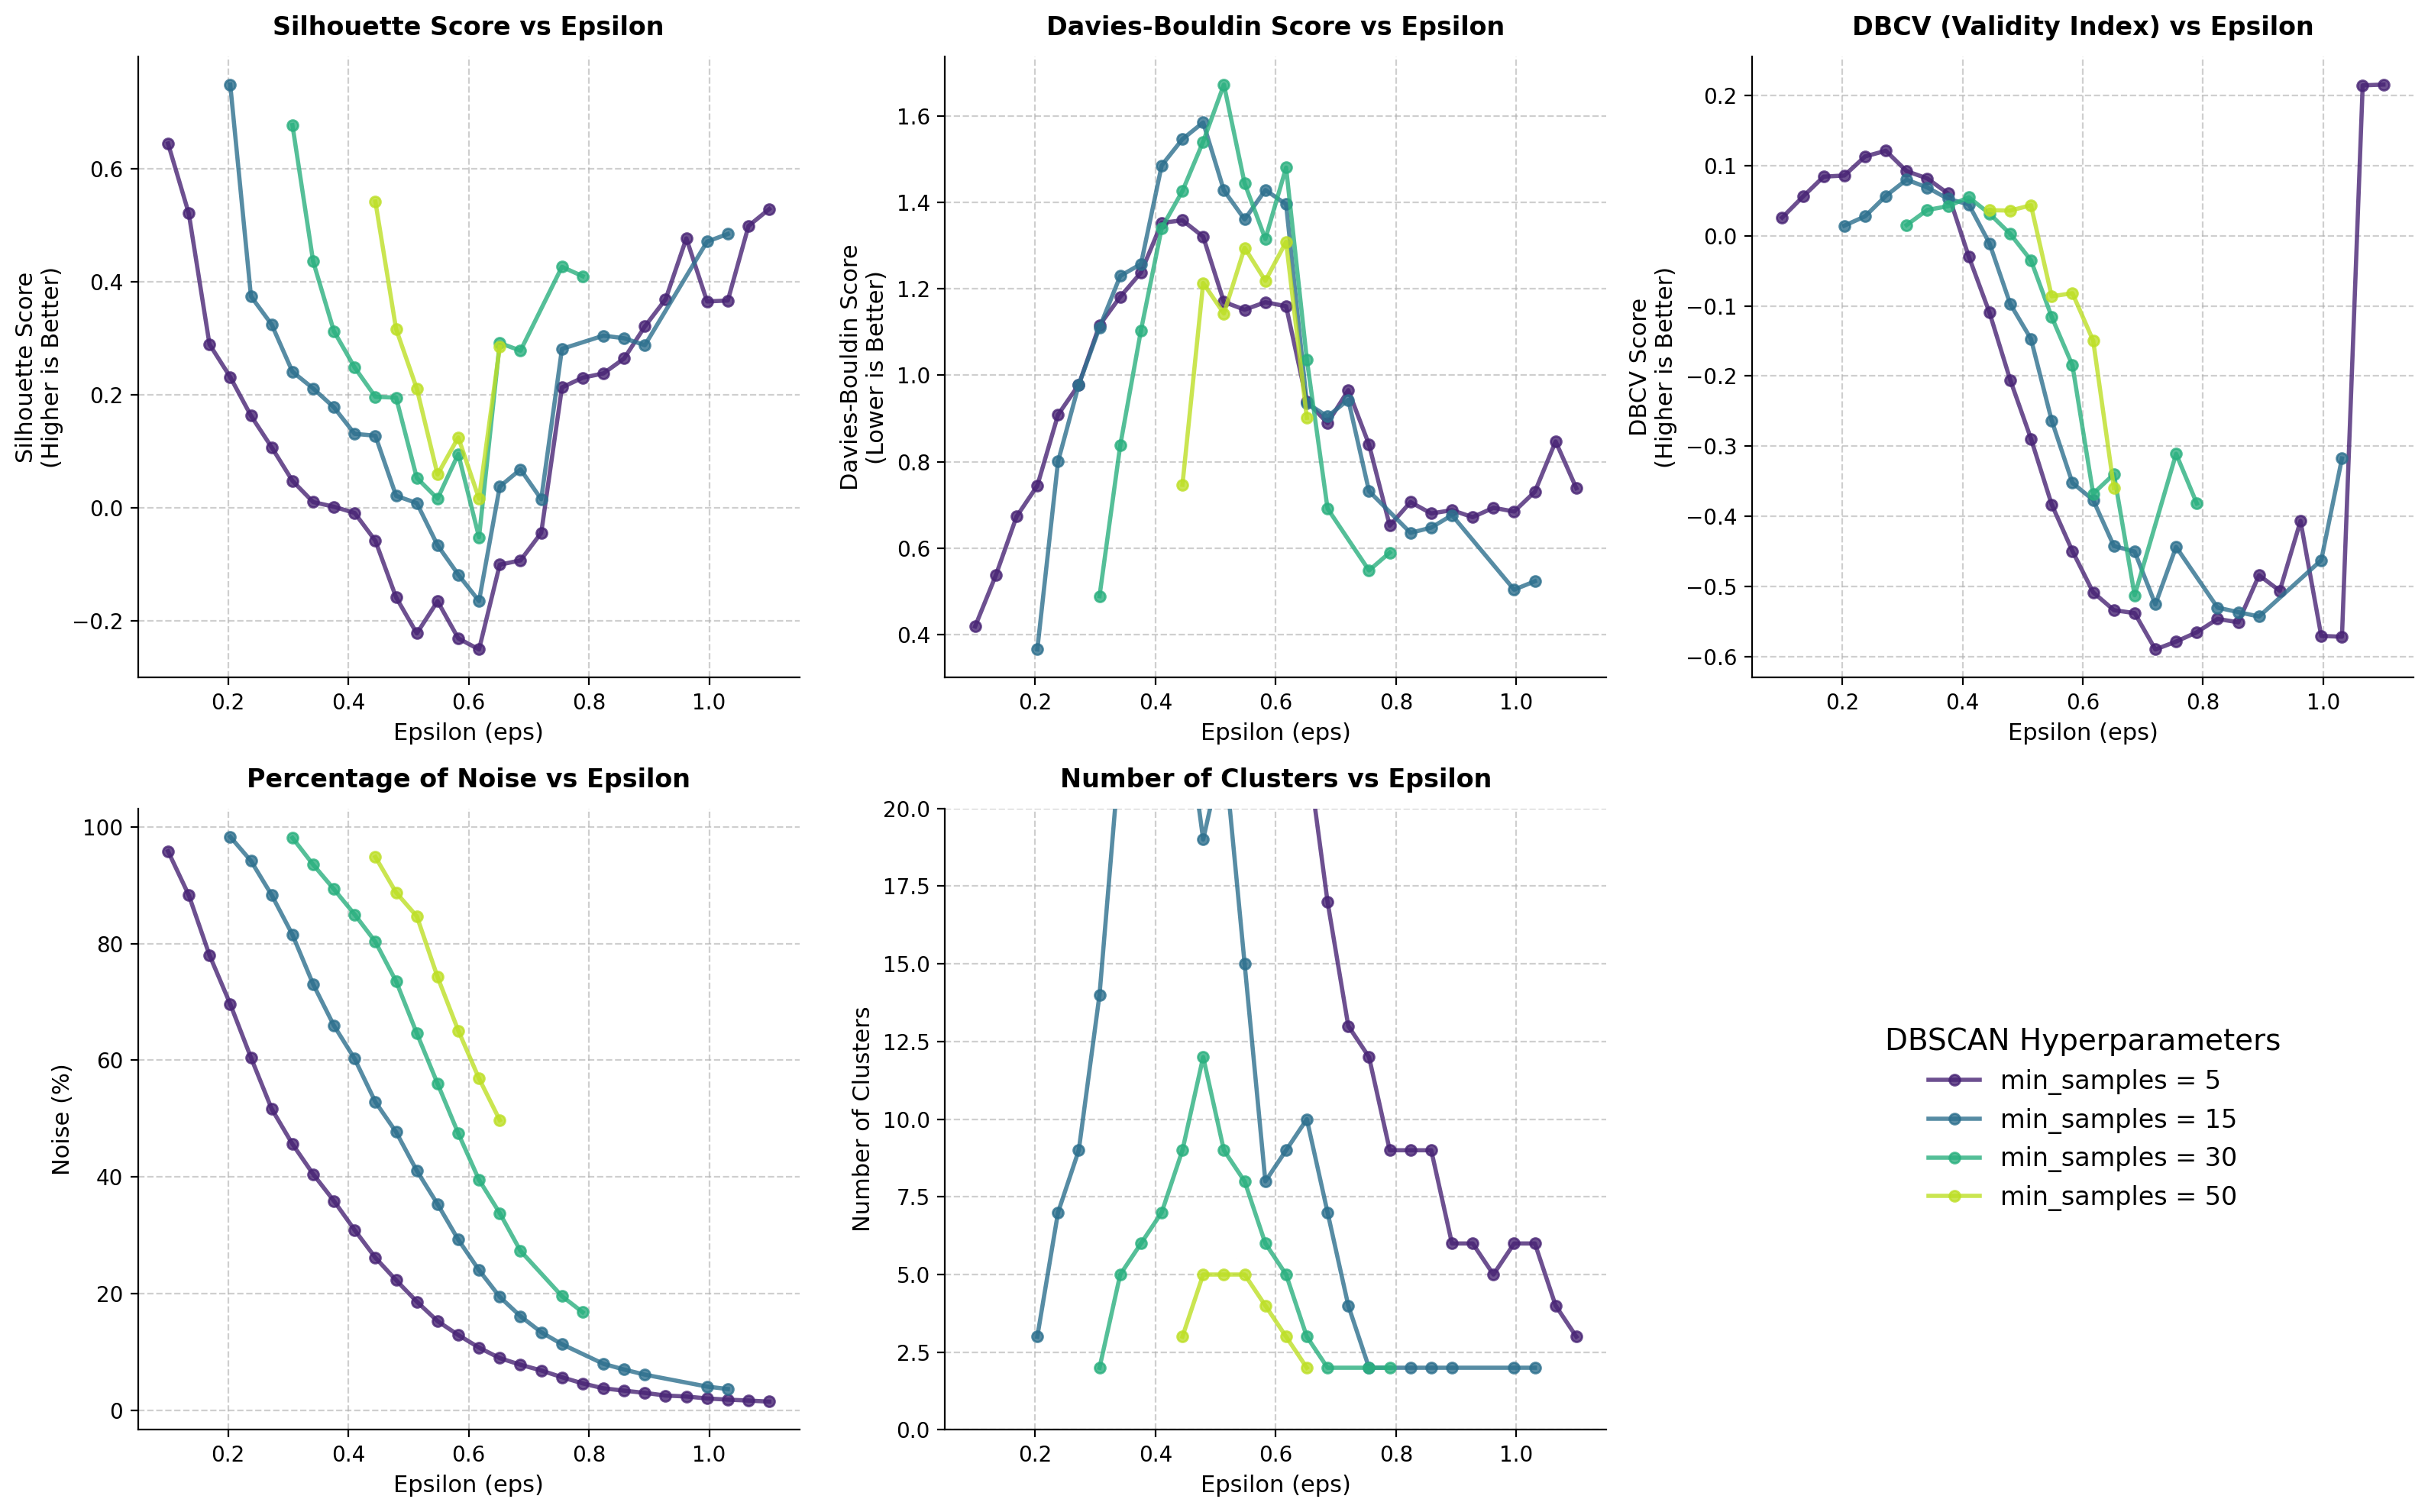

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from tqdm import tqdm
from hdbscan.validity import validity_index

# Define ranges for grid search
eps_range = np.linspace(0.1, 1.1, 30)

# Testing a range of densities for 5000 samples (from 0.1% to 1% of the data)
min_samples_range = [5, 15, 30, 50]  

# Dictionary to store results for each min_samples value
results = {ms: {'eps': [], 'sil': [], 'db': [], 'dbcv': [], 'noise': [], 'n_clusters': []} for ms in min_samples_range}

for ms in min_samples_range:
    for eps in tqdm(eps_range, desc=f"Evaluating DBSCAN (min_samples={ms})"):
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels = dbscan.fit_predict(scaled_matrix)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        
        if n_clusters < 2:
            continue  # Skip if we don't have at least 2 clusters
            
        valid_mask = (labels != -1)
        if len(set(labels[valid_mask])) < 2:
            continue
            
        sil = silhouette_score(scaled_matrix[valid_mask], labels[valid_mask])
        db = davies_bouldin_score(scaled_matrix[valid_mask], labels[valid_mask])
        percent_noise = np.mean(labels == -1) * 100
        
        try:
            dbcv = validity_index(scaled_matrix, labels, metric='euclidean')
        except ValueError:
            dbcv = np.nan
            
        results[ms]['eps'].append(eps)
        results[ms]['sil'].append(sil)
        results[ms]['db'].append(db)
        results[ms]['dbcv'].append(dbcv)
        results[ms]['noise'].append(percent_noise)
        results[ms]['n_clusters'].append(n_clusters)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=200)
axes = axes.flatten()

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(min_samples_range)))

plot_configs = [
    {'key': 'sil', 'title': 'Silhouette Score vs Epsilon', 'ylabel': 'Silhouette Score\n(Higher is Better)'},
    {'key': 'db', 'title': 'Davies-Bouldin Score vs Epsilon', 'ylabel': 'Davies-Bouldin Score\n(Lower is Better)'},
    {'key': 'dbcv', 'title': 'DBCV (Validity Index) vs Epsilon', 'ylabel': 'DBCV Score\n(Higher is Better)'},
    {'key': 'noise', 'title': 'Percentage of Noise vs Epsilon', 'ylabel': 'Noise (%)'},
    {'key': 'n_clusters', 'title': 'Number of Clusters vs Epsilon', 'ylabel': 'Number of Clusters'}
]

for i, ms in enumerate(min_samples_range):
    if not results[ms]['eps']:
        continue
        
    c = colors[i]
    
    for j, config in enumerate(plot_configs):
        label = f'min_samples = {ms}' if j == 0 else ""
        
        axes[j].plot(results[ms]['eps'], results[ms][config['key']], 
                     marker='o', markersize=5, linewidth=2, color=c, label=label, alpha=0.8)

# 3. Format the subplots
for j, config in enumerate(plot_configs):
    axes[j].set_title(config['title'], fontsize=12, fontweight='bold', pad=10)
    axes[j].set_xlabel('Epsilon (eps)', fontsize=11)
    axes[j].set_ylabel(config['ylabel'], fontsize=11)
    axes[j].grid(True, linestyle='--', alpha=0.6)
    
    # Remove top and right spines for a cleaner look
    axes[j].spines['top'].set_visible(False)
    axes[j].spines['right'].set_visible(False)

# 4. Handle the 6th (empty) subplot and use it for a master legend
axes[4].set_ylim(0, 20)
axes[5].axis('off') # Hide the axis lines and ticks

# Extract the handles and labels from the first subplot to create the unified legend
handles, labels = axes[0].get_legend_handles_labels()
axes[5].legend(handles, labels, loc='center', fontsize=12, 
               title='DBSCAN Hyperparameters', title_fontsize=14, frameon=False)

plt.tight_layout()
plt.show()

In [7]:
labels = DBSCAN(eps=0.9, min_samples=5).fit_predict(scaled_matrix)
df = df.with_columns(pl.Series("cluster_label", labels))
np.unique(labels, return_counts=True)

(array([-1,  0,  1,  2,  3,  4,  5]),
 array([ 141, 4795,    5,   32,   11,    6,   10]))

In [8]:
reducer = 'PCA'
create_chemiscope_viewer(df, scaled_matrix, labels=labels, reduction_method=reducer)

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

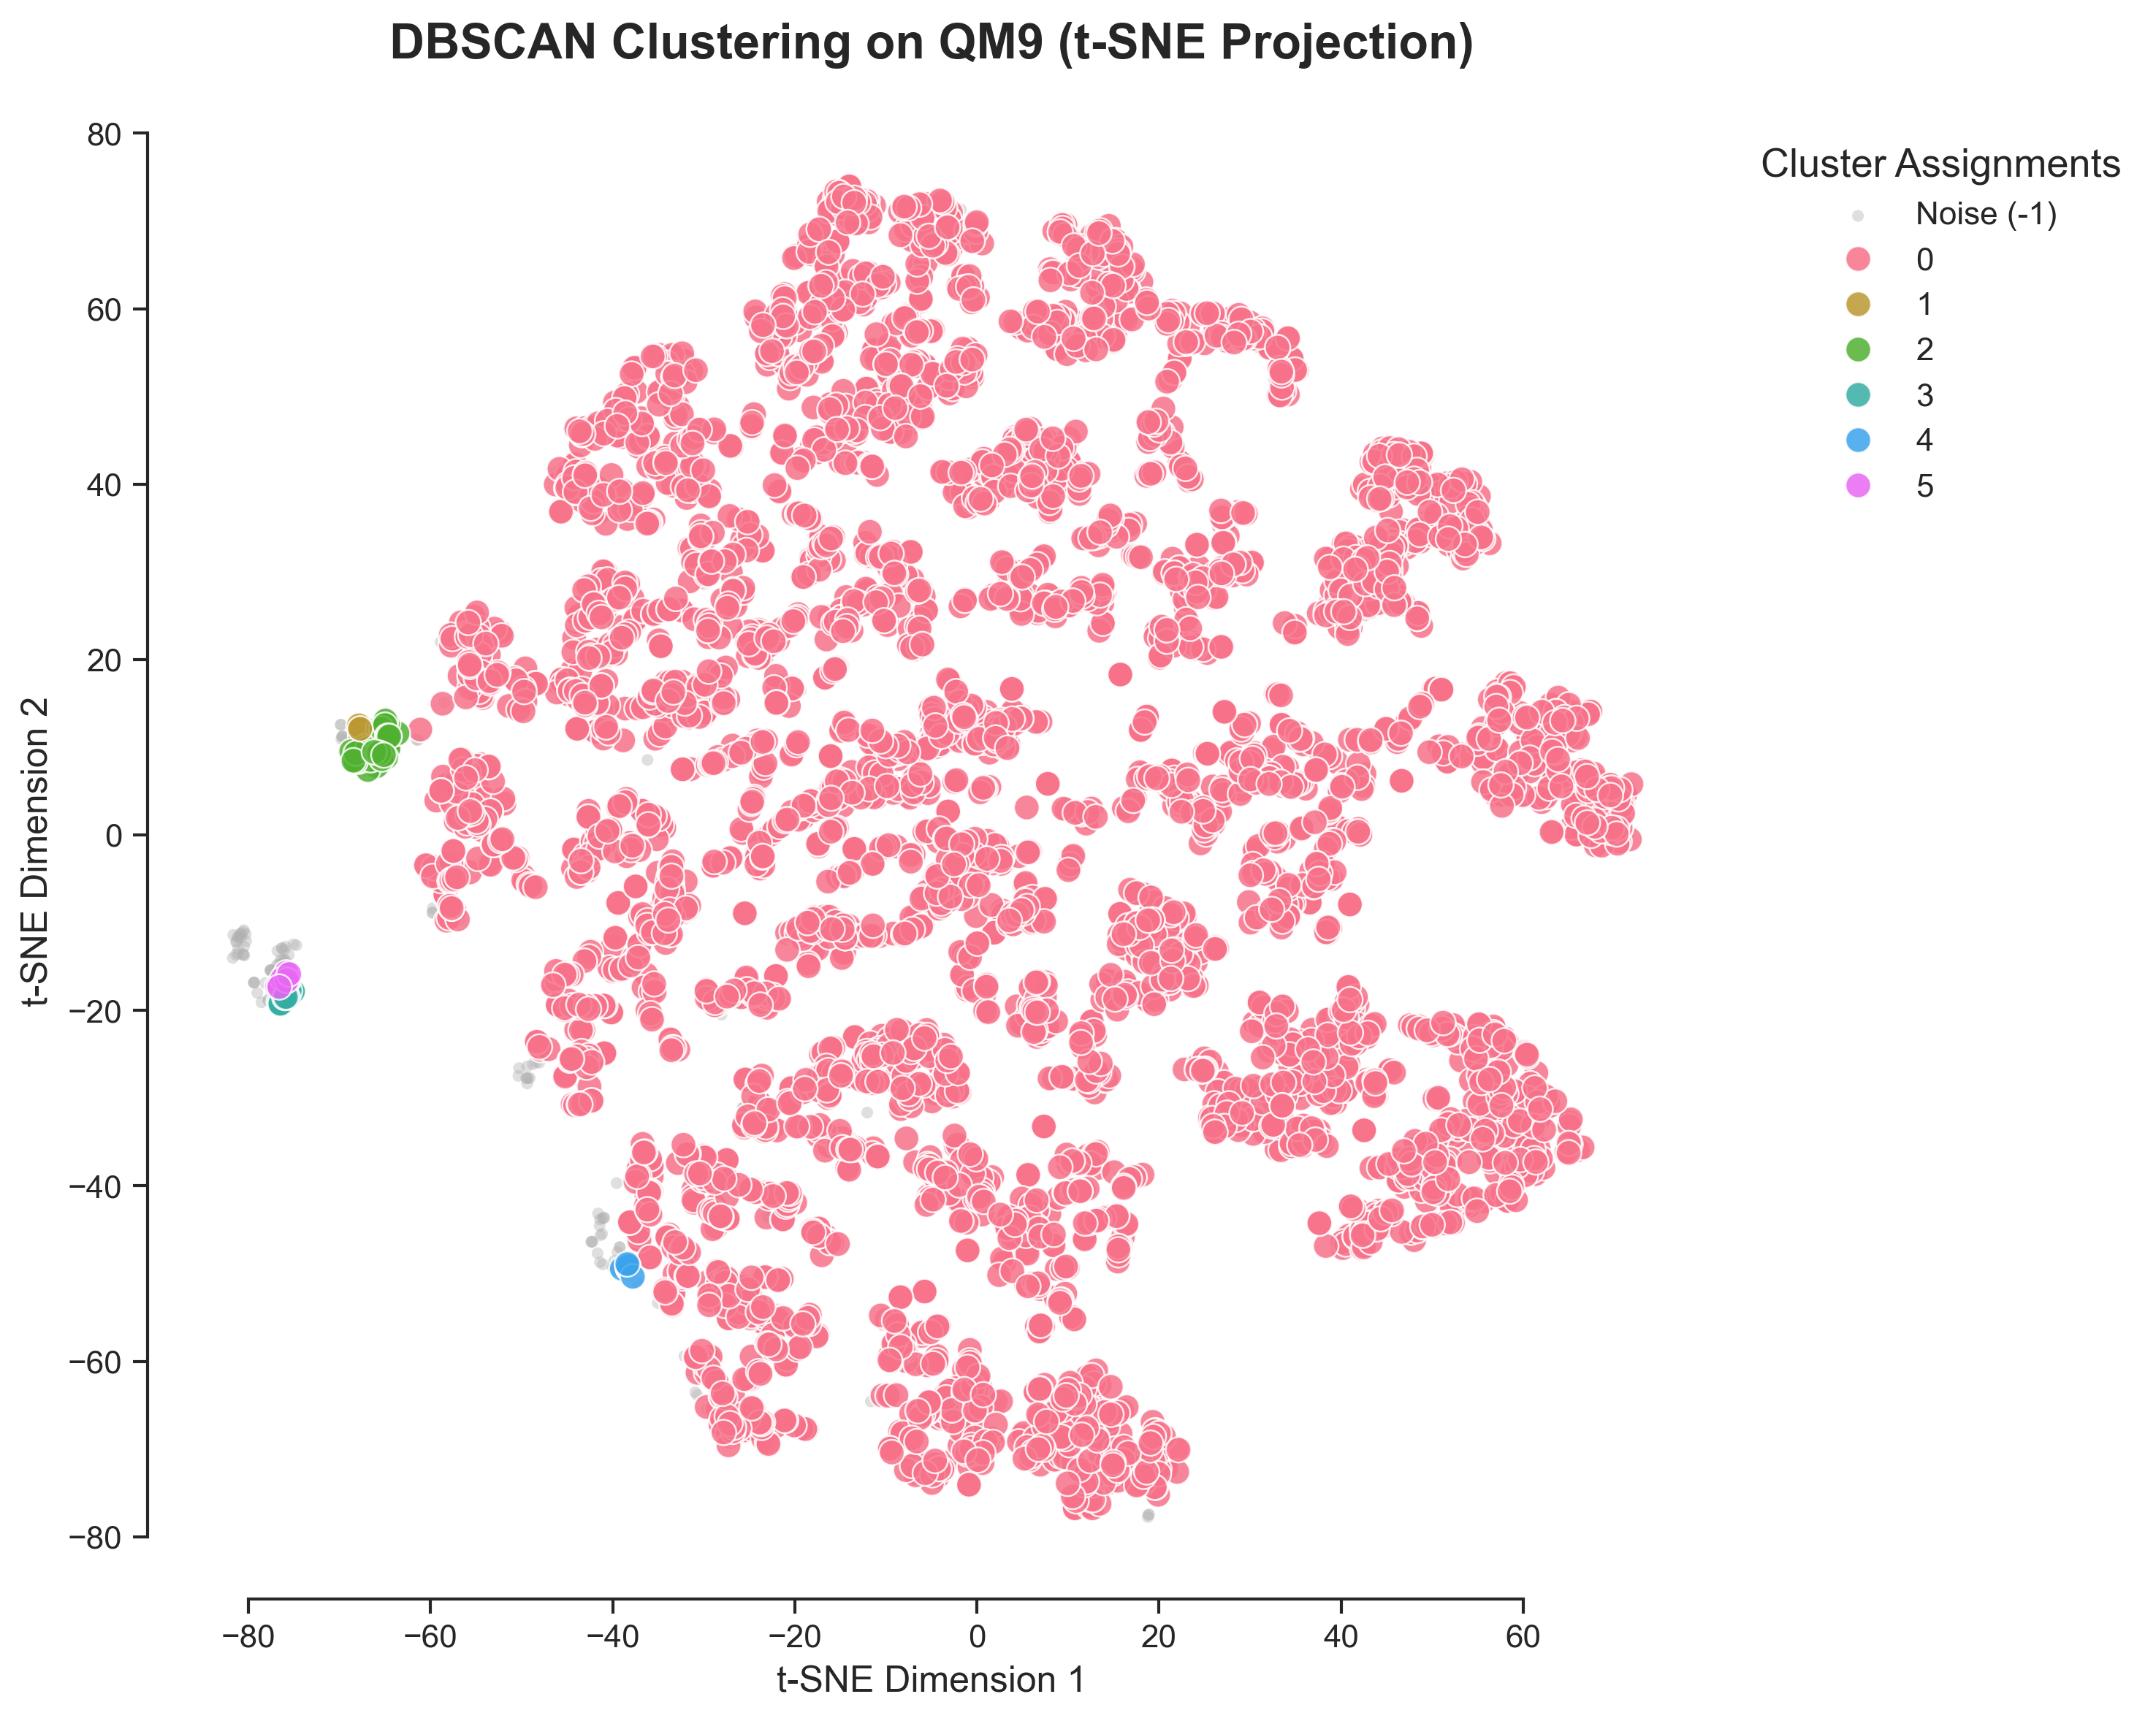

In [9]:
from sklearn.manifold import TSNE
# t-SNE reducer
tsne = TSNE(n_components=2, random_state=42)
pca_embedding = tsne.fit_transform(scaled_matrix)

# 2. Setup Professional Plot Style
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 8), dpi=300) # High DPI makes it crisp for papers/presentations

# Convert labels to numpy array for boolean masking
labels = np.array(labels)
unique_labels = np.unique(labels)
n_clusters = len([l for l in unique_labels if l != -1])

# 3. Plot Noise First (so it stays in the background!)
noise_mask = (labels == -1)
if noise_mask.any():
    ax.scatter(
        pca_embedding[noise_mask, 0], 
        pca_embedding[noise_mask, 1], 
        c='#B0B0B0',        # Soft silver/grey
        s=15,               # Smaller size
        alpha=0.4,          # Highly transparent
        label='Noise (-1)',
        edgecolors='none'
    )

# 4. Plot the Valid Clusters
cluster_mask = (labels != -1)
if cluster_mask.any():
    # Use a vibrant, visually pleasing palette
    palette = sns.color_palette("husl", n_clusters)
    
    sns.scatterplot(
        x=pca_embedding[cluster_mask, 0], 
        y=pca_embedding[cluster_mask, 1], 
        hue=labels[cluster_mask], 
        palette=palette,
        s=70,               # Larger size for valid points
        alpha=0.85,         # Slight transparency to show density
        edgecolor='white',  # Adds a crisp outline to overlapping points
        linewidth=0.6,
        ax=ax,
        legend='full'
    )

# 5. Typography and Labels
ax.set_title('DBSCAN Clustering on QM9 (t-SNE Projection)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='medium')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='medium')

# 6. Clean up the box/axes (Despine)
sns.despine(trim=True, offset=5)

# 7. Legend Formatting
# Move legend outside the plot, remove its ugly box
ax.legend(title="Cluster Assignments", 
          bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          frameon=False, 
          title_fontsize='13')

plt.tight_layout()

# Save it as a high-quality image (optional)
plt.savefig("figures/qm9/clustering/dbscan/invariant_features/dbscan_tsne_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

In [10]:
def average_numeric_by_cluster(df: pl.DataFrame) -> pl.DataFrame:
    """
    Groups a Polars DataFrame by 'cluster_label' and returns 
    the mean of all numeric columns along with the count of elements.
    """
    return (
        df.group_by("cluster_label")
        .agg(
            pl.len().alias("count"),  # Adds the number of elements per cluster
            pl.col(pl.NUMERIC_DTYPES).mean()
        )
        .sort("cluster_label")
    )

print("DBSCAN")
cluster_averages = average_numeric_by_cluster(df)
with pl.Config(set_tbl_cols=-1, set_tbl_width_chars=1000, set_tbl_rows=-1):
    print(cluster_averages)


DBSCAN
shape: (7, 55)
┌───────────────┬───────┬───────────┬────────────┬──────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬───────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┐
│ cluster_label ┆ count ┆ num_atoms ┆ mol_weight ┆ logp     ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ num_rings ┆ num_aromatic_rings ┆ coordination ┆

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_72341/1161311280.py:10: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).mean()
